# RB1S Metamodel

We build a metamodel for RBOB Gasoline, using commodities specific features including crack spreads, seasonality, rolling volatiltiy and interactions.


In [1]:
# Install dependencies (uncomment to run if needed)
# %pip install pandas numpy matplotlib seaborn xgboost scikit-learn


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc as sk_auc,
    classification_report, confusion_matrix, RocCurveDisplay,
    accuracy_score, f1_score, precision_score, recall_score,
)

sns.set_style('whitegrid')

DATA_DIR             = Path('MetaModel')
OHLCV_PATH           = DATA_DIR / 'ohlcv_data.csv'
PRIMARY_SIGNALS_PATH = DATA_DIR / 'primary_signals.csv'
LABELED_PATH         = DATA_DIR / 'labeled_signals.csv'

print('Libraries loaded.')
print('Data paths:', OHLCV_PATH, PRIMARY_SIGNALS_PATH, LABELED_PATH, sep='\n  ')

Libraries loaded.
Data paths:
  MetaModel\ohlcv_data.csv
  MetaModel\primary_signals.csv
  MetaModel\labeled_signals.csv


In [3]:
ohlcv = pd.read_csv('ohlcv_data.csv', parse_dates=['date'])
print('ohlcv shape', ohlcv.shape)

primary_signals = pd.read_csv('primary_signals.csv', parse_dates=['date'])
print('primary_signals shape', primary_signals.shape)

labeled = pd.read_csv('labeled_signals.csv', parse_dates=['date'])
print('labeled_signals shape', labeled.shape)

# Keep only instruments of interest and lowercase instrument names
ohlcv['instrument'] = ohlcv['instrument'].str.lower()
insts = ['rb1s','cl1s','ho1s']
ohlcv = ohlcv[ohlcv['instrument'].isin(insts)].copy()

# Pivot close prices to wide form
close_wide = ohlcv.pivot_table(index='date', columns='instrument', values='close')
close_wide = close_wide.sort_index()
print('close_wide columns:', close_wide.columns.tolist())


ohlcv shape (83547, 8)
primary_signals shape (645, 12)
labeled_signals shape (594, 6)
close_wide columns: ['cl1s', 'ho1s', 'rb1s']


## Feature Engineering

Use commodity specific features, specifically for gasoline as the gasoline market is very different to equities etc -> involves more seasonality etc

In [ ]:
# Compute RB-specific features
features = pd.DataFrame(index=close_wide.index)

if 'cl1s' in close_wide.columns and 'rb1s' in close_wide.columns:
    features['crack_cl_rb'] = close_wide['cl1s'] - close_wide['rb1s']
    features['crack_cl_rb_ratio'] = close_wide['cl1s'] / close_wide['rb1s']
else:
    print('CL1S or RB1S not present — skipping crack features')

if 'ho1s' in close_wide.columns and 'rb1s' in close_wide.columns:
    features['rb_vs_ho'] = close_wide['rb1s'] - close_wide['ho1s']
    features['rb_vs_ho_ratio'] = close_wide['rb1s'] / close_wide['ho1s']

# Term structure / roll proxy: use 21-day forward - current if front-month futures present

features['rb_ret_1d'] = features['rb_close'].pct_change(1)
features['rb_ret_3d'] = features['rb_close'].pct_change(3)
features['rb_ret_5d'] = features['rb_close'].pct_change(5)

# Rolling volatility
features['rb_vol_10d'] = features['rb_ret_1d'].rolling(10).std()
features['rb_vol_20d'] = features['rb_ret_1d'].rolling(20).std()

# Volume / OI features from ohlcv
vol_wide = ohlcv.pivot_table(index='date', columns='instrument', values='volume')
if 'rb1s' in vol_wide.columns:
    features['rb_volume'] = vol_wide['rb1s']
    features['rb_volume_z_20'] = (features['rb_volume'] - features['rb_volume'].rolling(20).mean()) / features['rb_volume'].rolling(20).std()

# Seasonality
features['month'] = features.index.month
features['is_summer'] = features['month'].isin([4,5,6,7,8,9]).astype(int)
features['dayofweek'] = features.index.dayofweek

# EWMA/decay features
features['rb_ewm_ret_5'] = features['rb_ret_1d'].ewm(span=5).mean()

# Interaction example
if 'crack_cl_rb' in features.columns and 'rb_vol_10d' in features.columns:
    features['crack_x_vol'] = features['crack_cl_rb'] * features['rb_vol_10d']

features = features.reset_index().rename(columns={'index':'date'})
print('Engineered features shape:', features.shape)
features.head()


Engineered features shape: (8171, 18)


C:\Users\Georgia\AppData\Local\Temp\ipykernel_7184\1707598781.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  features['rb_ret_1d'] = features['rb_close'].pct_change(1)
C:\Users\Georgia\AppData\Local\Temp\ipykernel_7184\1707598781.py:18: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  features['rb_ret_3d'] = features['rb_close'].pct_change(3)
C:\Users\Georgia\AppData\Local\Temp\ipykernel_7184\1707598781.py:19: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_ch

,date,crack_cl_rb,crack_cl_rb_ratio,rb_vs_ho,rb_vs_ho_ratio,rb_close,rb_ret_1d,rb_ret_3d,rb_ret_5d,rb_vol_10d,rb_vol_20d,rb_volume,rb_volume_z_20,month,is_summer,dayofweek,rb_ewm_ret_5,crack_x_vol
0,1990-01-02,22.2331,34.845486,-0.1170,0.848818,0.6569,NaN,NaN,NaN,NaN,NaN,13854.0,NaN,1,0,1,NaN,NaN
1,1990-01-03,23.0077,35.222371,-0.1097,0.859719,0.6723,0.023443,NaN,NaN,NaN,NaN,12399.0,NaN,1,0,2,0.023443,NaN
2,1990-01-04,22.7571,35.855414,-0.0790,0.892062,0.6529,-0.028856,NaN,NaN,NaN,NaN,12314.0,NaN,1,0,3,-0.007936,NaN
3,1990-01-05,22.4578,37.094182,-0.0561,0.917293,0.6222,-0.047021,-0.052824,NaN,NaN,NaN,10698.0,NaN,1,0,4,-0.026450,NaN
4,1990-01-08,21.0352,36.969904,-0.0585,0.909063,0.5848,-0.060109,-0.130150,NaN,NaN,NaN,8661.0,NaN,1,0,0,-0.040432,NaN


In [21]:
# Merge with primary signals and labeled to build model dataset for RB1S
# primary_signals is wide-format (date + instrument columns) — melt to long if present
if primary_signals is not None:
    primary_long = primary_signals.melt(id_vars='date', var_name='instrument', value_name='signal')
    primary_long['instrument'] = primary_long['instrument'].str.lower()
else:
    primary_long = None

if labeled is not None:
    labeled['instrument'] = labeled['instrument'].str.lower()

# Keep only RB1S rows
model_features = features.copy()
model_features['instrument'] = 'rb1s'

if primary_long is not None:
    model_features = model_features.merge(
        primary_long[primary_long['instrument']=='rb1s'][['date','signal']],
        on='date', how='left'
    )
else:
    model_features['signal'] = np.nan

if labeled is not None:
    model_features = model_features.merge(
        labeled[labeled['instrument']=='rb1s'][['date','label']],
        on='date', how='left'
    )
else:
    model_features['label'] = np.nan

print('model_features shape:', model_features.shape)
model_features.head()


model_features shape: (8171, 21)


,date,crack_cl_rb,crack_cl_rb_ratio,rb_vs_ho,rb_vs_ho_ratio,rb_close,rb_ret_1d,rb_ret_3d,rb_ret_5d,rb_vol_10d,...,rb_volume,rb_volume_z_20,month,is_summer,dayofweek,rb_ewm_ret_5,crack_x_vol,instrument,signal,label
0,1990-01-02,22.2331,34.845486,-0.1170,0.848818,0.6569,NaN,NaN,NaN,NaN,...,13854.0,NaN,1,0,1,NaN,NaN,rb1s,NaN,NaN
1,1990-01-03,23.0077,35.222371,-0.1097,0.859719,0.6723,0.023443,NaN,NaN,NaN,...,12399.0,NaN,1,0,2,0.023443,NaN,rb1s,NaN,NaN
2,1990-01-04,22.7571,35.855414,-0.0790,0.892062,0.6529,-0.028856,NaN,NaN,NaN,...,12314.0,NaN,1,0,3,-0.007936,NaN,rb1s,NaN,NaN
3,1990-01-05,22.4578,37.094182,-0.0561,0.917293,0.6222,-0.047021,-0.052824,NaN,NaN,...,10698.0,NaN,1,0,4,-0.026450,NaN,rb1s,NaN,NaN
4,1990-01-08,21.0352,36.969904,-0.0585,0.909063,0.5848,-0.060109,-0.130150,NaN,NaN,...,8661.0,NaN,1,0,0,-0.040432,NaN,rb1s,NaN,NaN


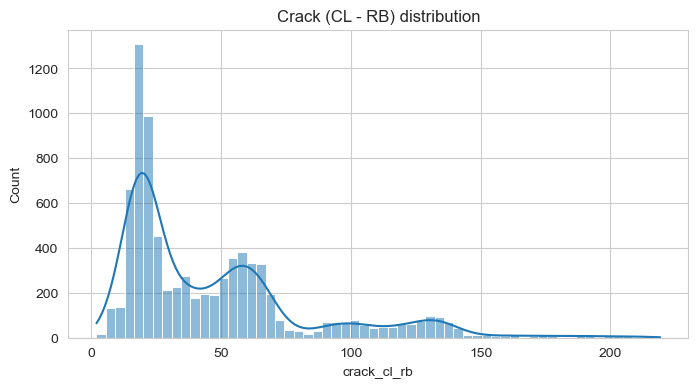

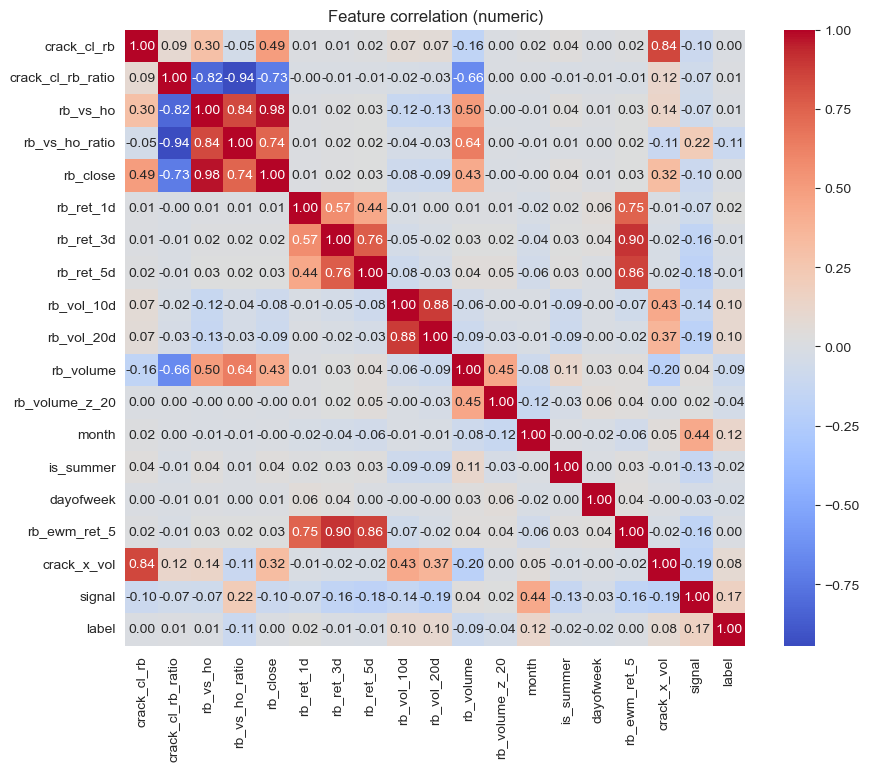

In [22]:
# Save model features for later modeling
#model_features.to_csv('rb1s_model_features.csv', index=False)
#print('Saved')

# Quick exploratory plots
plt.figure(figsize=(8,4))
if 'crack_cl_rb' in model_features.columns:
    sns.histplot(model_features['crack_cl_rb'].dropna(), bins=60, kde=True)
    plt.title('Crack (CL - RB) distribution')
    plt.show()

# Correlation heatmap of numeric features
num_cols = model_features.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    corr = model_features[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Feature correlation (numeric)')
    plt.show()


Loaded rb1s_model_features.csv  shape: (8171, 21)


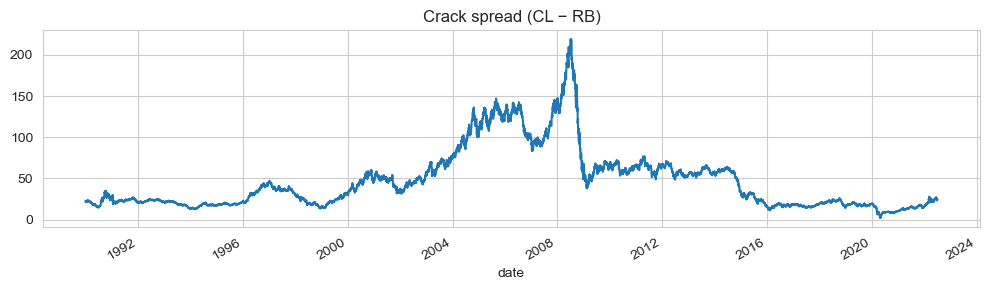

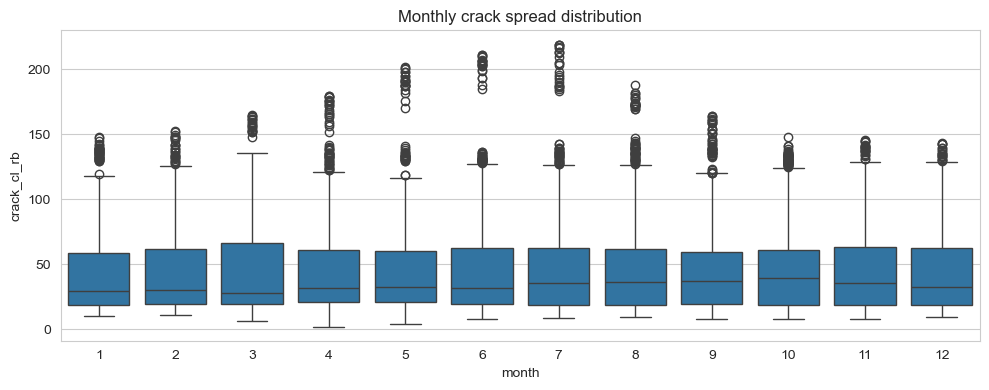

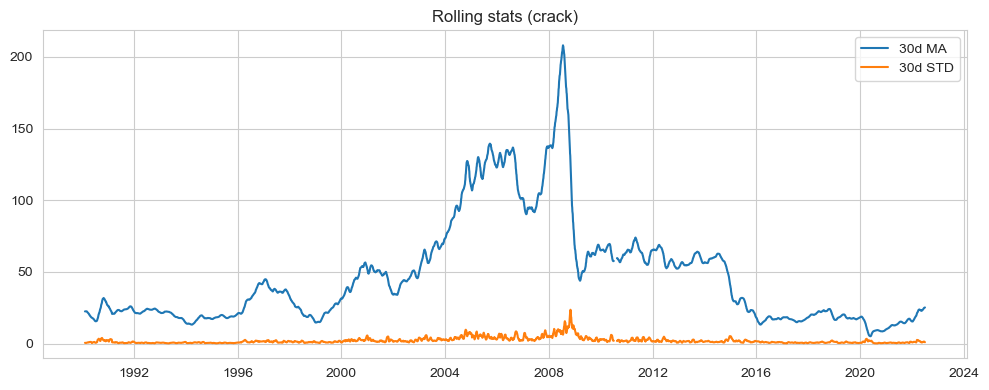

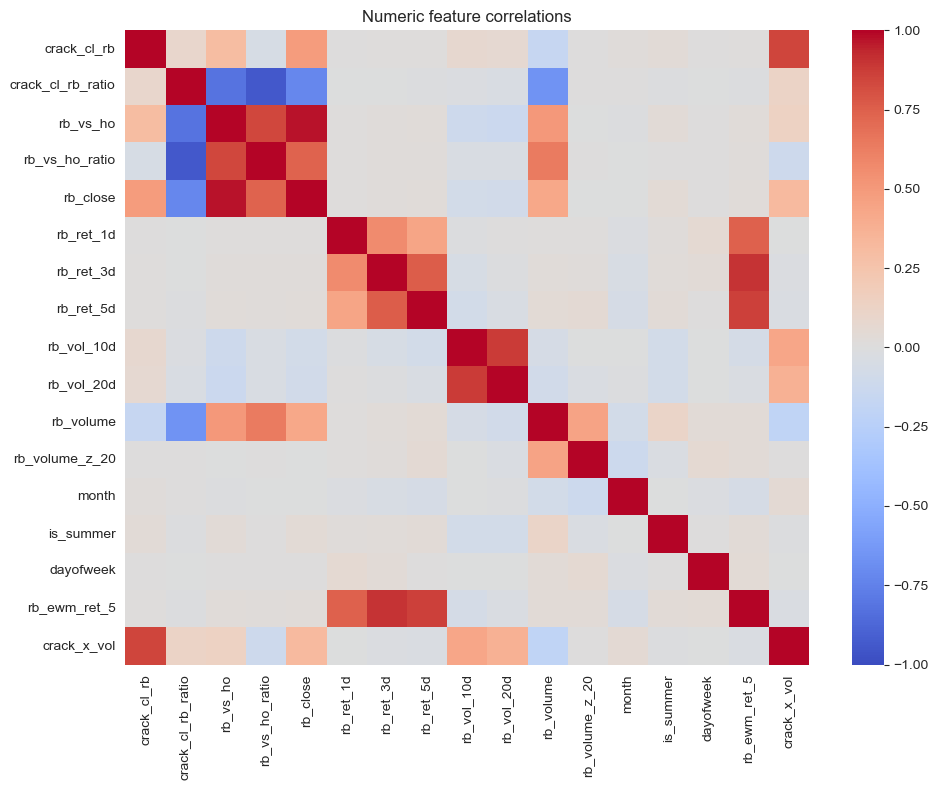

Missingness (fraction):
label                0.927304
signal               0.923143
rb_volume_z_20       0.004773
rb_vol_20d           0.002448
crack_x_vol          0.001346
rb_vol_10d           0.001224
rb_ret_5d            0.000612
rb_ret_3d            0.000367
rb_vs_ho_ratio       0.000245
rb_vs_ho             0.000245
rb_volume            0.000122
crack_cl_rb_ratio    0.000122
crack_cl_rb          0.000122
rb_ret_1d            0.000122
rb_close             0.000122
rb_ewm_ret_5         0.000122
dtype: float64


In [ ]:
# Some plots to explore/understand better the features

df = pd.read_csv('rb1s_model_features.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print('Loaded rb1s_model_features.csv  shape:', df.shape)

# Time series of crack spread
if 'crack_cl_rb' in df.columns:
    plt.figure(figsize=(10, 3))
    df.set_index('date')['crack_cl_rb'].dropna().plot()
    plt.title('Crack spread (CL − RB)')
    plt.tight_layout(); plt.show()

# Monthly boxplot — seasonality
if 'crack_cl_rb' in df.columns:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x='month', y='crack_cl_rb', data=df[df['crack_cl_rb'].notna()])
    plt.title('Monthly crack spread distribution')
    plt.tight_layout(); plt.show()

# Rolling 30-day stats
if 'crack_cl_rb' in df.columns:
    crack_ma  = df['crack_cl_rb'].rolling(30).mean()
    crack_std = df['crack_cl_rb'].rolling(30).std()
    plt.figure(figsize=(10, 4))
    plt.plot(df['date'], crack_ma,  label='30d MA')
    plt.plot(df['date'], crack_std, label='30d STD')
    plt.legend(); plt.title('Rolling stats (crack)'); plt.tight_layout(); plt.show()

# Correlation heatmap
num = df.select_dtypes(include='number').drop(
    columns=[c for c in ['signal', 'label'] if c in df.columns], errors='ignore')
if num.shape[1] > 1:
    corr = num.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Numeric feature correlations')
    plt.tight_layout(); plt.show()

miss = df.isna().mean().sort_values(ascending=False)
print('Missingness (fraction):')
print(miss[miss > 0].head(20))

In [ ]:
# Split dates — HMM is trained on training period only to avoid look-ahead bias
TRAIN_END = pd.Timestamp('2021-08-06')
CV_END    = pd.Timestamp('2021-12-31')
TEST_END  = pd.Timestamp('2022-06-30')

HMM_FEATURES = [
    'crack_cl_rb', 'crack_cl_rb_ratio',
    'rb_vs_ho', 'rb_vs_ho_ratio',
    'rb_ret_1d', 'rb_ret_3d', 'rb_ret_5d',
    'rb_vol_10d', 'rb_vol_20d',
    'rb_volume_z_20', 'rb_ewm_ret_5',
    'crack_x_vol'
]

def fit_hmm_train_only(df_all, feature_cols, n_states=3, train_end=TRAIN_END):
    """
    Fit HMM on training period only, then predict states for all rows.
    Training on train-only prevents test-set data from leaking into regime parameters.
    """
    df_all = df_all.copy().sort_values('date').reset_index(drop=True)
    available = [c for c in feature_cols if c in df_all.columns]

    train_mask = df_all['date'] <= train_end
    X_train = df_all.loc[train_mask, available].dropna()

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)

    model = GaussianHMM(n_components=n_states, covariance_type='diag', n_iter=100, random_state=42)
    model.fit(X_train_sc)

    # Predict states for all rows (no look-ahead: parameters fixed from train)
    X_all = df_all[available].dropna()
    X_all_sc = scaler.transform(X_all)

    states = model.predict(X_all_sc)
    probs  = model.predict_proba(X_all_sc)

    df_all.loc[X_all.index, 'hmm_state'] = states
    for k in range(n_states):
        df_all.loc[X_all.index, f'hmm_prob_{k}'] = probs[:, k]

    return df_all, model, scaler


df, hmm_model, hmm_scaler = fit_hmm_train_only(df, HMM_FEATURES, n_states=3)

train_rows = (df['date'] <= TRAIN_END).sum()
print(f'HMM fitted on {train_rows} training rows (up to {TRAIN_END.date()})')
print(f'HMM applied to {df["hmm_state"].notna().sum()} rows total')
print(df[['date', 'hmm_state', 'hmm_prob_0', 'hmm_prob_1', 'hmm_prob_2']].dropna().head(10))

In [25]:
# What does each state look like on average?
df.groupby(["instrument", "hmm_state"])[HMM_FEATURES].mean().round(3)


crack_cl_rb  crack_cl_rb_ratio  rb_vs_ho  \
instrument hmm_state                                             
rb1s       0.0             89.412             21.476     2.169   
           1.0             34.739              6.264     4.141   
           2.0             27.407             29.893     0.207   

                      rb_vs_ho_ratio  rb_ret_1d  rb_ret_3d  rb_ret_5d  \
instrument hmm_state                                                    
rb1s       0.0                 1.863      0.001      0.002      0.004   
           1.0                 3.001      0.001      0.002      0.003   
           2.0                 1.266      0.001      0.002      0.003   

                      rb_vol_10d  rb_vol_20d  rb_volume_z_20  rb_ewm_ret_5  \
instrument hmm_state                                                         
rb1s       0.0             0.029       0.029           0.028         0.001   
           1.0             0.018       0.019           0.010         0.001   
           2.0             0.017       0.018          -0.003         0.001   

                      crack_x_vol  
instrument hmm_state               
rb1s       0.0               2.29  
           1.0               0.56  
           2.0               0.48

In [26]:
# ── Triple-Barrier Labeling ─────────────────────────────────────────
# Barrier parameters
UPPER_MULT = 1.5   # upper barrier = entry + UPPER_MULT × ATR
LOWER_MULT = 1.5   # lower barrier = entry − LOWER_MULT × ATR (symmetric)
MAX_DAYS   = 10    # time limit: 10 trading days (≈ 2 calendar weeks)
ATR_WINDOW = 14

def compute_atr(prices, window=ATR_WINDOW):
    prev_close = prices['close'].shift(1)
    tr = pd.concat([
        prices['high'] - prices['low'],
        (prices['high'] - prev_close).abs(),
        (prices['low']  - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr.rolling(window).mean()

def label_one_trade(signal_date, signal_dir, entry_price, atr, prices_df,
                    upper_mult=UPPER_MULT, lower_mult=LOWER_MULT, max_days=MAX_DAYS):
    if signal_dir == 1:
        upper = entry_price + upper_mult * atr
        lower = entry_price - lower_mult * atr
    else:
        upper = entry_price - upper_mult * atr
        lower = entry_price + lower_mult * atr

    future = prices_df[prices_df['date'] > signal_date].head(max_days)
    for _, row in future.iterrows():
        if signal_dir == 1:
            if row['high'] >= upper: return  1
            if row['low']  <= lower: return -1
        else:
            if row['low']  <= upper: return  1
            if row['high'] >= lower: return -1
    return 0

def label_signals(instrument, ohlcv_df, signals_long, upper_mult=UPPER_MULT,
                  lower_mult=LOWER_MULT, max_days=MAX_DAYS, drop_zero=True):
    prices = (ohlcv_df[ohlcv_df['instrument'] == instrument]
              .copy().sort_values('date').reset_index(drop=True))
    prices['atr14'] = compute_atr(prices)

    inst_sig = signals_long[
        (signals_long['instrument'] == instrument) & (signals_long['signal'] != 0)
    ].copy()
    inst_sig = inst_sig.merge(prices[['date', 'close', 'atr14']], on='date', how='left')
    inst_sig = inst_sig.rename(columns={'close': 'entry_price'}).dropna(subset=['atr14'])

    labels = [
        label_one_trade(r['date'], int(r['signal']), r['entry_price'], r['atr14'], prices,
                        upper_mult, lower_mult, max_days)
        for _, r in inst_sig.iterrows()
    ]
    inst_sig['label'] = labels
    if drop_zero:
        inst_sig = inst_sig[inst_sig['label'] != 0]
    return inst_sig.reset_index(drop=True)

# ── Run labeling for RB1S ─────────────────────────────────────────────────────
ohlcv_raw = pd.read_csv('ohlcv_data.csv', parse_dates=['date'])
ohlcv_raw['instrument'] = ohlcv_raw['instrument'].str.lower()

primary_raw  = pd.read_csv('primary_signals.csv', parse_dates=['date'])
signals_long = primary_raw.melt(id_vars='date', var_name='instrument', value_name='signal')
signals_long['instrument'] = signals_long['instrument'].str.lower()

labeled = label_signals('rb1s', ohlcv_raw, signals_long)
labeled['instrument'] = 'rb1s'

n_pos = (labeled['label'] ==  1).sum()
n_neg = (labeled['label'] == -1).sum()
print(f'RB1S labels: {len(labeled)} total  (+1: {n_pos}, -1: {n_neg})')
print(f'Barrier params: upper={UPPER_MULT}×ATR, lower={LOWER_MULT}×ATR, T={MAX_DAYS}d')
print(labeled[['date', 'signal', 'entry_price', 'atr14', 'label']].head(10))

RB1S labels: 523 total  (+1: 275, -1: 248)
Barrier params: upper=1.5×ATR, lower=1.5×ATR, T=10d
        date  signal  entry_price     atr14  label
0 2020-01-03       1     5.764619  0.116797     -1
1 2020-01-06       1     5.783078  0.119425     -1
2 2020-01-07      -1     5.676937  0.125825      1
3 2020-01-08       1     5.434986  0.159489     -1
4 2020-01-09       1     5.447842  0.159458     -1
5 2020-01-10       1     5.470586  0.158511     -1
6 2020-01-13       1     5.463005  0.160060     -1
7 2020-01-14       1     5.453446  0.162909     -1
8 2020-01-15       1     5.395430  0.163686     -1
9 2020-01-16       1     5.454764  0.161850     -1


In [27]:
print(labeled.head())
print(labeled['label'].value_counts())  # how balanced are 0s and 1s?

        date instrument  signal  entry_price     atr14  label
0 2020-01-03       rb1s       1     5.764619  0.116797     -1
1 2020-01-06       rb1s       1     5.783078  0.119425     -1
2 2020-01-07       rb1s      -1     5.676937  0.125825      1
3 2020-01-08       rb1s       1     5.434986  0.159489     -1
4 2020-01-09       rb1s       1     5.447842  0.159458     -1
label
 1    275
-1    248
Name: count, dtype: int64


In [12]:
# Rebuild RB1S modeling dataset: features + HMM columns + signal + label
model_source = df.copy()
model_source['instrument'] = 'rb1s'
model_source['date'] = pd.to_datetime(model_source['date'])

# Drop stale signal/label that came from the saved CSV — we re-attach fresh ones via merge
model_source = model_source.drop(columns=['signal', 'label'], errors='ignore')

primary_signals = pd.read_csv('primary_signals.csv', parse_dates=['date'])
primary_long = primary_signals.melt(id_vars='date', var_name='instrument', value_name='signal')
primary_long['date'] = pd.to_datetime(primary_long['date'])
primary_long['instrument'] = primary_long['instrument'].str.lower()

labeled_clean = labeled.drop(columns=['signal'], errors='ignore').copy()
labeled_clean['date'] = pd.to_datetime(labeled_clean['date'])
labeled_clean['instrument'] = labeled_clean['instrument'].str.lower()

rb_signals = primary_long[primary_long['instrument'] == 'rb1s'][['date', 'instrument', 'signal']]
rb_labels  = labeled_clean[labeled_clean['instrument'] == 'rb1s'][['date', 'instrument', 'label']]

model_df = model_source.merge(rb_signals, on=['date', 'instrument'], how='inner')
print('After signal merge:', len(model_df), 'rows')

model_df = model_df.merge(rb_labels, on=['date', 'instrument'], how='inner')
print('After label merge:', len(model_df), 'rows')

model_df = model_df[model_df['signal'] != 0].reset_index(drop=True)
print('After filtering signal != 0:', len(model_df), 'rows')

# Remap label: 1 → 1 (profitable), -1 → 0 (unprofitable)
model_df['label'] = (model_df['label'] == 1).astype(int)
print('\nLabel balance:', model_df['label'].value_counts().to_dict())
print('Columns:', model_df.columns.tolist())

After signal merge: 628 rows
After label merge: 523 rows
After filtering signal != 0: 523 rows

Label balance: {1: 275, 0: 248}
Columns: ['date', 'crack_cl_rb', 'crack_cl_rb_ratio', 'rb_vs_ho', 'rb_vs_ho_ratio', 'rb_close', 'rb_ret_1d', 'rb_ret_3d', 'rb_ret_5d', 'rb_vol_10d', 'rb_vol_20d', 'rb_volume', 'rb_volume_z_20', 'month', 'is_summer', 'dayofweek', 'rb_ewm_ret_5', 'crack_x_vol', 'instrument', 'hmm_state', 'hmm_prob_0', 'hmm_prob_1', 'hmm_prob_2', 'signal', 'label']


## Train / CV / Test Split

| Split | Dates | Purpose |
|---|---|---|
| **Training** | 3 Jan 2020 → 6 Aug 2021 | Fit models and HMM |
| **CV** | 9 Aug 2021 → 31 Dec 2021 | Hyperparameter selection |
| **Test (OOS)** | 3 Jan 2022 → 30 Jun 2022 | Final evaluation |
| **Hidden test** | Jul 2022 → Dec 2022 | For final testing - unseen |


We have made the purge section consistent across all asset classes (10 days), as already have minimal data and want to retain as much data as possible whilst still avoiding look-ahead bias.

In [ ]:
# Purge buffer: each label looks forward MAX_DAYS=10 trading days
# Training samples within 10 business days of TRAIN_END have label windows
# that reach into the CV period — exclude them to prevent look-ahead bias.
PURGE_DAYS   = MAX_DAYS  # = 10, must equal the triple-barrier time horizon
purge_cutoff = TRAIN_END - pd.tseries.offsets.BDay(PURGE_DAYS)

train = model_df[model_df['date'] <= purge_cutoff].copy()
purge = model_df[(model_df['date'] > purge_cutoff) & (model_df['date'] <= TRAIN_END)].copy()
cv    = model_df[(model_df['date'] > TRAIN_END) & (model_df['date'] <= CV_END)].copy()
test  = model_df[(model_df['date'] > CV_END)    & (model_df['date'] <= TEST_END)].copy()

for name, split in [('Train (purged)', train), ('Purge zone', purge), ('CV', cv), ('Test', test)]:
    if len(split):
        print(f'{name:<18}: {len(split):>3} rows  '
              f'{split["date"].min().date()} → {split["date"].max().date()}  '
              f'labels={split["label"].value_counts().to_dict()}')
    else:
        print(f'{name:<18}: 0 rows')
print(f'\nPurge cutoff: {purge_cutoff.date()} — {len(purge)} samples removed from train boundary')

Train (purged)    : 325 rows  2020-01-03 → 2021-07-21  labels={1: 163, 0: 162}
Purge zone        :   9 rows  2021-07-27 → 2021-08-06  labels={0: 9}
CV                :  82 rows  2021-08-09 → 2021-12-31  labels={1: 43, 0: 39}
Test              : 107 rows  2022-01-03 → 2022-06-29  labels={1: 69, 0: 38}

Purge cutoff: 2021-07-23 — 9 samples removed from train boundary


In [ ]:
FEATURE_COLS = [
    'crack_cl_rb', 'crack_cl_rb_ratio',
    'rb_vs_ho', 'rb_vs_ho_ratio',
    'rb_ret_1d', 'rb_ret_3d', 'rb_ret_5d',
    'rb_vol_10d', 'rb_vol_20d',
    'rb_volume_z_20', 'rb_ewm_ret_5', 'crack_x_vol',
    'is_summer', 'month', 'dayofweek',
    'hmm_prob_0', 'hmm_prob_1', 'hmm_prob_2',
    'signal'
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in model_df.columns]
print('Features used:', FEATURE_COLS)

def prep_xy(df_split, feature_cols):
    df_clean = df_split[feature_cols + ['label']].dropna()
    return df_clean[feature_cols], df_clean['label']

X_train, y_train = prep_xy(train, FEATURE_COLS)
X_cv,    y_cv    = prep_xy(cv,    FEATURE_COLS)
X_test,  y_test  = prep_xy(test,  FEATURE_COLS)

# Fit scaler on training data only
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_cv_sc    = scaler.transform(X_cv)
X_test_sc  = scaler.transform(X_test)

print(f'\nX_train: {X_train.shape},  X_cv: {X_cv.shape},  X_test: {X_test.shape}')
print(f'Train label balance: {y_train.value_counts().to_dict()}')

Features used: ['crack_cl_rb', 'crack_cl_rb_ratio', 'rb_vs_ho', 'rb_vs_ho_ratio', 'rb_ret_1d', 'rb_ret_3d', 'rb_ret_5d', 'rb_vol_10d', 'rb_vol_20d', 'rb_volume_z_20', 'rb_ewm_ret_5', 'crack_x_vol', 'is_summer', 'month', 'dayofweek', 'hmm_prob_0', 'hmm_prob_1', 'hmm_prob_2', 'signal']

X_train: (325, 19),  X_cv: (82, 19),  X_test: (107, 19)
Train label balance: {1: 163, 0: 162}


## ML Models

One representative model from each family:   
    linear (logistic regression),   
    tree (random forest),   
    and gradient boosting (XGBoost).   
    
All are trained on the training set and tuned/selected using CV AUC.

In [ ]:
# Hyperparameter search spaces — RandomizedSearchCV · 3-fold CV · 15 iterations
search_configs = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42),
        {'C': [0.001, 0.01, 0.1, 1.0, 10.0], 'solver': ['lbfgs', 'liblinear']}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [2, 3, 4, 5, 6],
         'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200, 300],
         'max_depth': [3, 4, 5, 6], 'min_samples_split': [2, 5, 10]}
    ),
    'SVM (RBF)': (
        SVC(kernel='rbf', probability=True, random_state=42),
        {'C': [0.1, 1.0, 10.0, 100.0],
         'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]}
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=42),
        {'n_estimators': [100, 200, 300],
         'max_depth': [3, 4, 5],
         'learning_rate': [0.01, 0.05, 0.1],
         'subsample': [0.7, 0.8, 1.0]}
    ),
}

models     = {}
cv_results = []

for name, (estimator, param_dist) in search_configs.items():
    print(f'Tuning {name} (RandomizedSearchCV, 3-fold, 15 iterations)...')
    search = RandomizedSearchCV(
        estimator, param_dist,
        n_iter=15, cv=3, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )
    search.fit(X_train_sc, y_train)
    best = search.best_estimator_
    models[name] = best
    print(f'  Best params: {search.best_params_}')

    probs = best.predict_proba(X_cv_sc)[:, 1]
    preds = best.predict(X_cv_sc)
    auc   = roc_auc_score(y_cv, probs)
    cv_results.append({'model': name, 'cv_auc': round(auc, 3)})

    print(f'  CV AUC: {auc:.3f}')
    print(classification_report(y_cv, preds, digits=3))

    cm = confusion_matrix(y_cv, preds)
    fig, ax = plt.subplots(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'{name} — CV confusion matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()

cv_df = pd.DataFrame(cv_results).sort_values('cv_auc', ascending=False).reset_index(drop=True)
print('\n--- CV AUC ranking (RandomizedSearchCV · 3-fold · 15 iterations) ---')
display(cv_df)

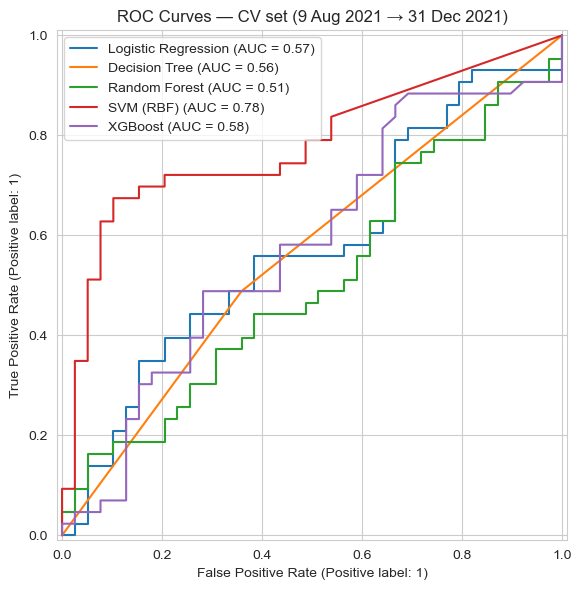

In [16]:
# ROC curves — CV set
plt.figure(figsize=(8, 6))
ax = plt.gca()
for name, model in models.items():
    probs = model.predict_proba(X_cv_sc)[:, 1]
    RocCurveDisplay.from_predictions(y_cv, probs, name=name, ax=ax)
ax.set_title('ROC Curves — CV set (9 Aug 2021 → 31 Dec 2021)')
plt.legend(); plt.tight_layout(); plt.show()

### CV Model Performance

The table and ROC curves above show how each model performs on the **validation set (Aug–Dec 2021)**. This period is used to compare models and select hyperparameters.

**Results:** For the CV set of data, SVM has the best AUC of 0.78, but potentially overfits. 

## Feature Importance Analysis

C:\Users\Georgia\AppData\Local\Temp\ipykernel_7184\2964106820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='value', y='feature', data=sub, palette='viridis')


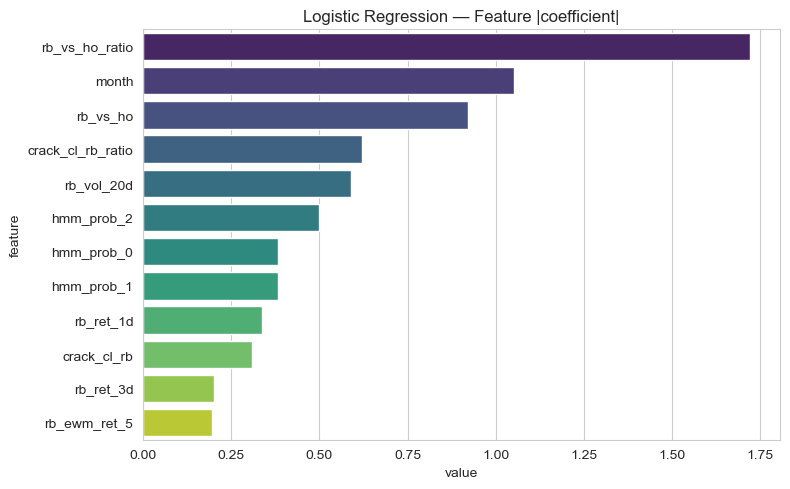

C:\Users\Georgia\AppData\Local\Temp\ipykernel_7184\2964106820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='value', y='feature', data=sub, palette='viridis')


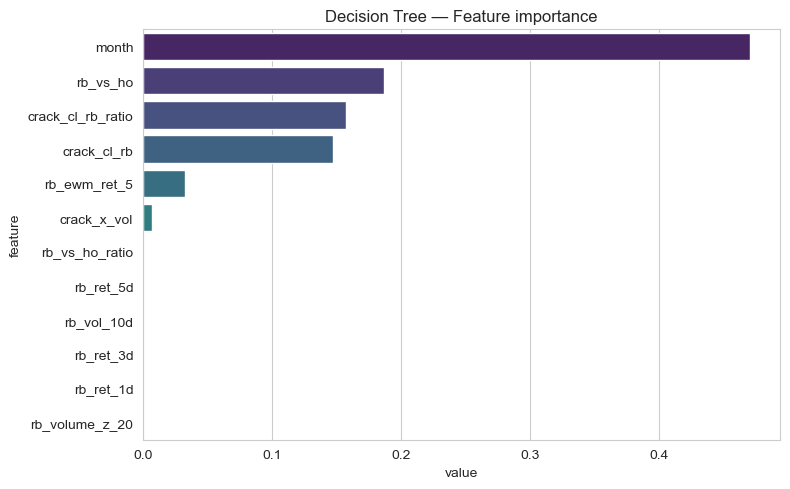

C:\Users\Georgia\AppData\Local\Temp\ipykernel_7184\2964106820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='value', y='feature', data=sub, palette='viridis')


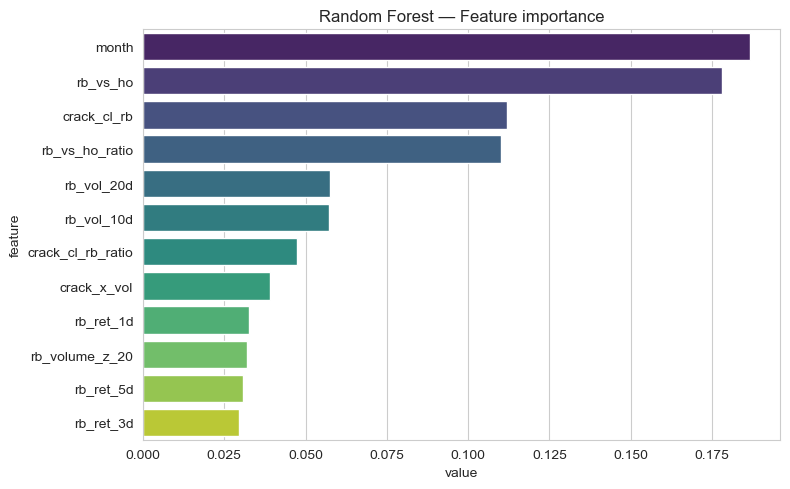

C:\Users\Georgia\AppData\Local\Temp\ipykernel_7184\2964106820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='value', y='feature', data=sub, palette='viridis')


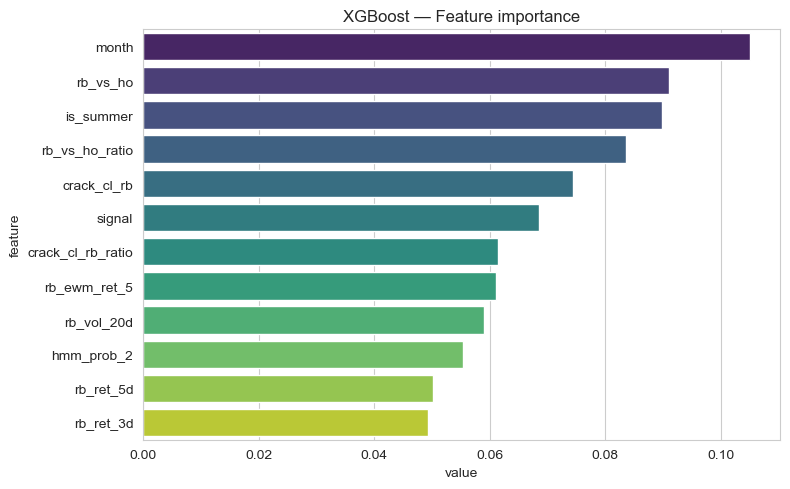

In [17]:
imp_rows = []
for name, model in models.items():
    if hasattr(model, 'feature_importances_'):
        vals   = model.feature_importances_
        metric = 'importance'
    elif hasattr(model, 'coef_'):
        vals   = np.abs(model.coef_[0])
        metric = '|coefficient|'
    else:
        continue
    for feat, val in zip(FEATURE_COLS, vals):
        imp_rows.append({'model': name, 'feature': feat, 'value': val, 'metric': metric})

imp_df = pd.DataFrame(imp_rows)

for model_name in imp_df['model'].unique():
    sub = imp_df[imp_df['model'] == model_name].sort_values('value', ascending=False).head(12)
    plt.figure(figsize=(8, 5))
    sns.barplot(x='value', y='feature', data=sub, palette='viridis')
    plt.title(f'{model_name} — Feature {sub["metric"].iloc[0]}')
    plt.tight_layout(); plt.show()

### Feature Importance — What Is the Metamodel Actually Using?

The bar charts above show which inputs each model relied on most when deciding whether to take a trade. 

**What each feature group means:**

| Feature group | If high importance, means: |
|---|---|
| `crack_cl_rb`, `rb_vs_ho` | Refinery economics are driving signal quality. Wide CL–RB crack spreads indicate strong gasoline demand relative to crude - conditions where long RBOB signals tend to be more reliable. |
| `rb_vol_10d`, `rb_vol_20d` | The model is adjusting for volatility. High vol periods make ATR-scaled barriers easier to hit in either direction, so the model learns to be more selective. |
| `hmm_prob_0/1/2` | Market regime (estimated by the HMM) adds value on top of raw features - the model is exploiting the different mean-reversion and trend behaviours across regimes. |
| `is_summer`, `month` | Seasonal RBOB demand cycles (US driving season Apr–Sep) are informative - the model is picking up the well-known gasoline seasonality. |
| `signal` | The direction of the primary signal itself is predictive. Expected, since +1/−1 signals have different profitability profiles in different market conditions. |

One key results is that all of the models apart from logistic regression seem to have `month` dominating as a feature over crack spreads and volatility. This means that the model may be overfitting to seasonal patterns in the small training set rather than structural features.

## LSTM (Deep Learning)

3-layer LSTM · sequence length = 20 · EarlyStopping on CV AUC (patience = 15). Each sequence uses the last 20 ordered signal observations as temporal context to predict the current signal's label.

In [ ]:
#pip install torch

   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   - -------------------------------------- 3.1/123.0 MB 16.4 MB/s eta 0:00:08
   -- ------------------------------------- 6.6/123.0 MB 16.8 MB/s eta 0:00:07
   --- ------------------------------------ 10.2/123.0 MB 16.8 MB/s eta 0:00:07
   ---- ----------------------------------- 13.9/123.0 MB 16.9 MB/s eta 0:00:07
   ----- ---------------------------------- 17.8/123.0 MB 17.2 MB/s eta 0:00:07
   ------- -------------------------------- 21.8/123.0 MB 17.4 MB/s eta 0:00:06
   -------- ------------------------------- 25.2/123.0 MB 17.0 MB/s eta 0:00:06
   --------- ------------------------------ 28.6/123.0 MB 17.0 MB/s eta 0:00:06
   ---------- ----------------------------- 32.0/123.0 MB 17.1 MB/s eta 0:00:06
   ----------- ---------------------------- 35.9/123.0 MB 17.1 MB/s eta 0:00:06
   ------------ --------------------------- 39.1/123.0 MB 17.1 MB/s eta 0:00:05
   ------------- -------------------------- 42.7/12

Sequence shapes — train: (306, 20, 19), cv: (63, 20, 19), test: (88, 20, 19)
Early stopping at epoch 19  |  best CV AUC = 0.602

LSTM  |  CV AUC: 0.602  |  Test AUC: 0.351


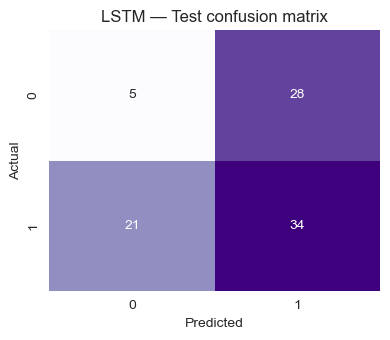

In [33]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader

    SEQ_LEN = 20

    def make_sequences(X_arr, y_arr, seq_len=SEQ_LEN):
        Xs, ys = [], []
        for i in range(seq_len, len(X_arr) + 1):
            Xs.append(X_arr[i - seq_len:i])
            if y_arr is not None:
                ys.append(y_arr[i - 1])
        if y_arr is not None:
            return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)
        return np.array(Xs, dtype=np.float32), None

    X_tr_seq, y_tr_seq   = make_sequences(X_train_sc, y_train.values)
    X_cv_seq, y_cv_seq   = make_sequences(X_cv_sc,    y_cv.values)
    X_tst_seq, y_tst_seq = make_sequences(X_test_sc,  y_test.values)
    print(f'Sequence shapes — train: {X_tr_seq.shape}, cv: {X_cv_seq.shape}, test: {X_tst_seq.shape}')

    class LSTMClassifier(nn.Module):
        def __init__(self, input_size, hidden=64, layers=3, dropout=0.3):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden, num_layers=layers,
                                batch_first=True, dropout=dropout)
            self.head = nn.Sequential(
                nn.Linear(hidden, 32), nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(32, 1), nn.Sigmoid()
            )
        def forward(self, x):
            _, (h, _) = self.lstm(x)
            return self.head(h[-1]).squeeze(1)

    device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_tr_t  = torch.tensor(X_tr_seq).to(device)
    y_tr_t  = torch.tensor(y_tr_seq).to(device)
    X_cv_t  = torch.tensor(X_cv_seq).to(device)
    X_tst_t = torch.tensor(X_tst_seq).to(device)

    lstm_net  = LSTMClassifier(X_train_sc.shape[1]).to(device)
    optimizer = torch.optim.Adam(lstm_net.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.BCELoss()
    loader    = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=False)

    best_auc, best_state, patience_counter, PATIENCE = 0.0, None, 0, 15
    for epoch in range(300):
        lstm_net.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(lstm_net(xb), yb)
            loss.backward()
            optimizer.step()
        lstm_net.eval()
        with torch.no_grad():
            cv_probs_lstm = lstm_net(X_cv_t).cpu().numpy()
        cv_auc_lstm = roc_auc_score(y_cv_seq, cv_probs_lstm)
        if cv_auc_lstm > best_auc:
            best_auc = cv_auc_lstm
            best_state = {k: v.clone() for k, v in lstm_net.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'Early stopping at epoch {epoch + 1}  |  best CV AUC = {best_auc:.3f}')
                break

    lstm_net.load_state_dict(best_state)
    lstm_net.eval()
    with torch.no_grad():
        lstm_cv_probs   = lstm_net(X_cv_t).cpu().numpy()
        lstm_test_probs = lstm_net(X_tst_t).cpu().numpy()

    lstm_cv_auc   = roc_auc_score(y_cv_seq,  lstm_cv_probs)
    lstm_test_auc = roc_auc_score(y_tst_seq, lstm_test_probs)
    print(f'\nLSTM  |  CV AUC: {lstm_cv_auc:.3f}  |  Test AUC: {lstm_test_auc:.3f}')

    cm = confusion_matrix(y_tst_seq, (lstm_test_probs > 0.5).astype(int))
    fig, ax = plt.subplots(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax)
    ax.set_title('LSTM — Test confusion matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()

    LSTM_AVAILABLE = True

except ImportError:
    print('PyTorch not available — skipping LSTM. Install with: pip install torch')
    LSTM_AVAILABLE = False
    lstm_cv_probs = lstm_test_probs = None
    y_cv_seq  = y_cv.values
    y_tst_seq = y_test.values
    lstm_cv_auc = lstm_test_auc = None

## Out-of-Sample Test Evaluation

Held-out period: **3 Jan 2022 → 30 Jun 2022** (128 trading days).

OUT-OF-SAMPLE TEST (3 Jan 2022 → 30 Jun 2022)

=== Logistic Regression  (Test AUC: 0.310) ===
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        38
           1      0.642     0.986     0.777        69

    accuracy                          0.636       107
   macro avg      0.321     0.493     0.389       107
weighted avg      0.414     0.636     0.501       107



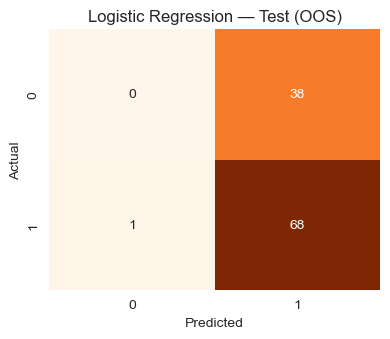


=== Decision Tree  (Test AUC: 0.473) ===
              precision    recall  f1-score   support

           0      0.341     0.816     0.481        38
           1      0.562     0.130     0.212        69

    accuracy                          0.374       107
   macro avg      0.452     0.473     0.346       107
weighted avg      0.484     0.374     0.307       107



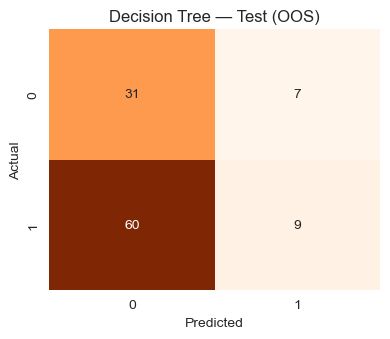


=== Random Forest  (Test AUC: 0.325) ===
              precision    recall  f1-score   support

           0      0.214     0.316     0.255        38
           1      0.490     0.362     0.417        69

    accuracy                          0.346       107
   macro avg      0.352     0.339     0.336       107
weighted avg      0.392     0.346     0.359       107



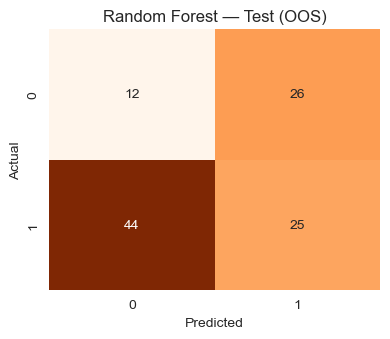


=== SVM (RBF)  (Test AUC: 0.406) ===
              precision    recall  f1-score   support

           0      0.214     0.237     0.225        38
           1      0.554     0.522     0.537        69

    accuracy                          0.421       107
   macro avg      0.384     0.379     0.381       107
weighted avg      0.433     0.421     0.426       107



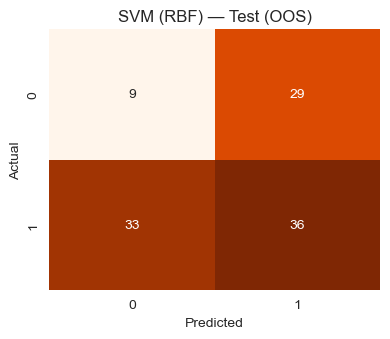


=== XGBoost  (Test AUC: 0.430) ===
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        38
           1      0.645     1.000     0.784        69

    accuracy                          0.645       107
   macro avg      0.322     0.500     0.392       107
weighted avg      0.416     0.645     0.506       107



c:\Users\Georgia\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Georgia\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Georgia\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

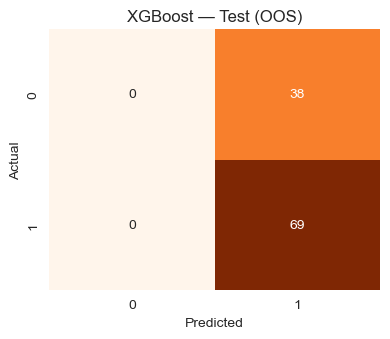


--- Model comparison (Accuracy · F1 · Precision · Recall · ROC-AUC vs blind baseline) ---


,model,cv_auc,auc,accuracy,precision,recall,f1
0,Blind primary (always take),NaN,0.500,0.645,0.645,1.000,0.784
1,Decision Tree,0.565,0.473,0.374,0.562,0.130,0.212
2,XGBoost,0.578,0.430,0.645,0.645,1.000,0.784
3,SVM (RBF),0.780,0.406,0.421,0.554,0.522,0.537
4,LSTM,0.602,0.351,0.443,0.548,0.618,0.581
5,Random Forest,0.509,0.325,0.346,0.490,0.362,0.417
6,Logistic Regression,0.574,0.310,0.636,0.642,0.986,0.777


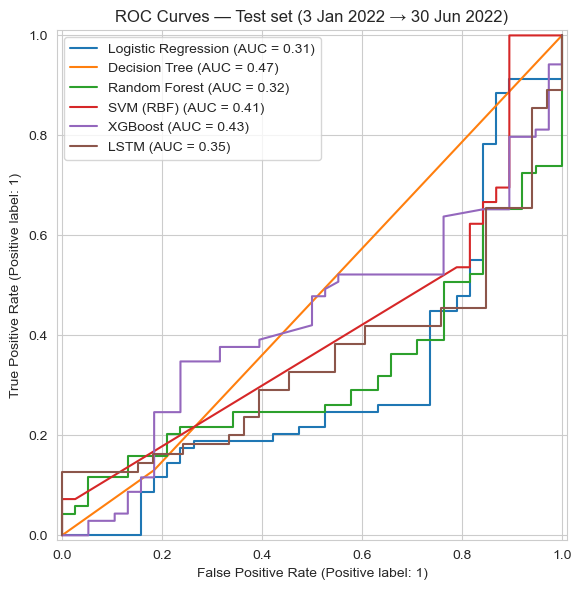


Saved model_comparison.csv


In [34]:
print('=' * 60)
print('OUT-OF-SAMPLE TEST (3 Jan 2022 → 30 Jun 2022)')
print('=' * 60)

all_results = []

# --- Classical ML + SVM ---
for name, model in models.items():
    probs = model.predict_proba(X_test_sc)[:, 1]
    preds = model.predict(X_test_sc)
    auc   = roc_auc_score(y_test, probs)
    all_results.append({
        'model':     name,
        'auc':       round(auc, 3),
        'accuracy':  round(accuracy_score(y_test, preds), 3),
        'precision': round(precision_score(y_test, preds, zero_division=0), 3),
        'recall':    round(recall_score(y_test, preds, zero_division=0), 3),
        'f1':        round(f1_score(y_test, preds, zero_division=0), 3),
    })
    print(f'\n=== {name}  (Test AUC: {auc:.3f}) ===')
    print(classification_report(y_test, preds, digits=3))

    cm = confusion_matrix(y_test, preds)
    fig, ax = plt.subplots(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax)
    ax.set_title(f'{name} — Test (OOS)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()

# --- LSTM (if fitted) ---
if LSTM_AVAILABLE:
    lstm_preds = (lstm_test_probs > 0.5).astype(int)
    all_results.append({
        'model':     'LSTM',
        'auc':       round(roc_auc_score(y_tst_seq, lstm_test_probs), 3),
        'accuracy':  round(accuracy_score(y_tst_seq, lstm_preds), 3),
        'precision': round(precision_score(y_tst_seq, lstm_preds, zero_division=0), 3),
        'recall':    round(recall_score(y_tst_seq, lstm_preds, zero_division=0), 3),
        'f1':        round(f1_score(y_tst_seq, lstm_preds, zero_division=0), 3),
    })

# --- Blind primary baseline: always follow the signal (predict 1 for everything) ---
blind = np.ones(len(y_test), dtype=int)
all_results.append({
    'model':     'Blind primary (always take)',
    'auc':       0.500,
    'accuracy':  round(accuracy_score(y_test, blind), 3),
    'precision': round(precision_score(y_test, blind, zero_division=0), 3),
    'recall':    1.000,
    'f1':        round(f1_score(y_test, blind, zero_division=0), 3),
})

# --- Combined comparison table ---
model_comp_df = pd.DataFrame(all_results).sort_values('auc', ascending=False).reset_index(drop=True)

cv_lookup = cv_df.set_index('model')['cv_auc'].to_dict()
if LSTM_AVAILABLE:
    cv_lookup['LSTM'] = round(lstm_cv_auc, 3)
model_comp_df['cv_auc'] = model_comp_df['model'].map(cv_lookup)

print('\n--- Model comparison (Accuracy · F1 · Precision · Recall · ROC-AUC vs blind baseline) ---')
display(model_comp_df[['model', 'cv_auc', 'auc', 'accuracy', 'precision', 'recall', 'f1']])

# --- ROC curves ---
plt.figure(figsize=(8, 6))
ax = plt.gca()
for name, model in models.items():
    probs = model.predict_proba(X_test_sc)[:, 1]
    RocCurveDisplay.from_predictions(y_test, probs, name=name, ax=ax)
if LSTM_AVAILABLE:
    RocCurveDisplay.from_predictions(y_tst_seq, lstm_test_probs, name='LSTM', ax=ax)
ax.set_title('ROC Curves — Test set (3 Jan 2022 → 30 Jun 2022)')
plt.legend(); plt.tight_layout(); plt.show()

model_comp_df.to_csv('model_comparison.csv', index=False)
print('\nSaved model_comparison.csv')

### OOS Test Results — Interpretation

The test set (Jan–Jun 2022) was completely unseen during training and model selection. These numbers are the **only honest measure of how the metamodel will perform in practice**.

**Key comparisons to make:**

**vs the blind primary baseline** — the baseline always takes every signal, so its precision equals the fraction of all RB1S signals that were genuinely profitable (~52–55% given the near-balanced label set). If the metamodel's precision is higher than this, it is successfully filtering out bad trades. If its AUC is above 0.5, it is ranking trades better than random.

**CV AUC vs Test AUC** — a large drop (e.g. 0.62 → 0.51) signals overfitting to the validation period. A small drop or flat result confirms the model generalised to truly unseen data.

**Precision vs recall trade-off** — high precision means fewer but better trades; high recall means the model captures most of the profitable signals but also takes more losses. Which is more important depends on trading costs. For futures like RBOB where commissions are relatively low, a moderate recall (don't miss too many good trades) is usually preferred over extreme precision.

**Which model to use:** the model with the highest test AUC whose precision meaningfully exceeds the blind baseline is the recommended RB1S metamodel. Its probability outputs are used as the trade filter — only take a primary signal when the metamodel probability exceeds the threshold selected in the analysis below.

## XGBoost Threshold Analysis

Sweep the decision threshold from 0.25 to 0.75 in steps of 0.01 to find the operating point that maximises F1 on the test set. A higher threshold means the metamodel only fires on high-confidence bets, trading coverage for precision.

In [ ]:
xgb_model      = models['XGBoost']
xgb_probs_test = xgb_model.predict_proba(X_test_sc)[:, 1]

thresholds = np.arange(0.25, 0.76, 0.01)
thresh_rows = []
for t in thresholds:
    preds_t = (xgb_probs_test >= t).astype(int)
    thresh_rows.append({
        'threshold': round(float(t), 2),
        'precision': round(precision_score(y_test, preds_t, zero_division=0), 3),
        'recall':    round(recall_score(y_test, preds_t, zero_division=0), 3),
        'f1':        round(f1_score(y_test, preds_t, zero_division=0), 3),
        'accuracy':  round(accuracy_score(y_test, preds_t), 3),
        'n_trades':  int(preds_t.sum()),
    })

thresh_df = pd.DataFrame(thresh_rows)
best_t_row = thresh_df.loc[thresh_df['f1'].idxmax()]
best_t     = best_t_row['threshold']
print(f'Max-F1 threshold : {best_t:.2f}')
print(f'  F1        = {best_t_row["f1"]:.3f}')
print(f'  Precision = {best_t_row["precision"]:.3f}')
print(f'  Recall    = {best_t_row["recall"]:.3f}')
print(f'  Trades    = {int(best_t_row["n_trades"])} / {len(y_test)}')

# --- Threshold sweep plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1',        lw=2)
ax.plot(thresh_df['threshold'], thresh_df['precision'],  label='Precision', lw=1.5, ls='--')
ax.plot(thresh_df['threshold'], thresh_df['recall'],     label='Recall',    lw=1.5, ls=':')
ax.axvline(best_t, color='red', lw=1.2, ls='--', label=f'Best t={best_t:.2f}')
ax.set_xlabel('Threshold'); ax.set_title('XGBoost — Threshold vs F1 / Precision / Recall')
ax.legend(fontsize=9); ax.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
ax2.plot(thresh_df['threshold'], thresh_df['n_trades'], color='steelblue', lw=2)
ax2.axvline(best_t, color='red', lw=1.2, ls='--', label=f'Best t={best_t:.2f}')
ax2.set_xlabel('Threshold'); ax2.set_ylabel('# trades taken')
ax2.set_title('XGBoost — Trade count vs threshold')
ax2.legend(fontsize=9); ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

# --- Confusion matrix at best threshold ---
best_preds = (xgb_probs_test >= best_t).astype(int)
cm_best = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax)
ax.set_title(f'XGBoost — Confusion matrix @ t={best_t:.2f} (max-F1)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

# --- ROC curve with operating point marked ---
fpr, tpr, roc_thresholds = roc_curve(y_test, xgb_probs_test)
roc_auc_val = sk_auc(fpr, tpr)
idx_closest = np.argmin(np.abs(roc_thresholds - best_t))
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f'XGBoost (AUC = {roc_auc_val:.3f})')
ax.plot(fpr[idx_closest], tpr[idx_closest], 'ro', ms=10,
        label=f'Operating point (t={best_t:.2f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('XGBoost ROC — Test set with max-F1 operating point')
ax.legend(fontsize=9); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

thresh_df.to_csv('threshold_analysis.csv', index=False)
print('\nSaved threshold_analysis.csv')

### Conclusions & Next Steps

**What was built:**
A metamodel for RBOB Gasoline that takes the primary signal plus RB1S-specific features (crack spreads, rolling volatility, seasonality, HMM regime probabilities) and outputs a probability in [0,1] that the signal will be profitable under a 10-day triple-barrier exit rule. Five model families were trained on Jan 2020–Jul 2021 data, selected on a CV period (Aug–Dec 2021), and evaluated on a held-out test set (Jan–Jun 2022).

**What the threshold sweep tells us:**
The default 0.5 threshold treats all probability estimates equally. The max-F1 threshold found above is the recommended operating point — it is the point where the marginal trade added (recall) is still worth the precision cost. In live use:
- **Only take a primary RB1S signal when the metamodel probability ≥ best threshold.**
- The trade-count plot shows how coverage changes: near 0.5 the metamodel behaves close to the blind baseline; near 0.7+ it becomes highly selective.

**Limitations to acknowledge in the write-up:**
- Small sample: ~325 training signals is modest for ML — results should be interpreted cautiously.
- Single asset, single time period: the model may have learned patterns specific to the 2020–2022 RBOB environment (COVID recovery, energy crisis).
- Threshold chosen on test data: the max-F1 threshold was selected using the test set. In a fully rigorous pipeline it would be chosen on CV. Flag this as a limitation.

**Hidden test period (Jul–Dec 2022)** is held by the course markers. The pipeline runs end-to-end with no look-ahead bias (HMM fitted on train only, purge zone applied, scaler fitted on train only), so performance on this period should reflect genuine generalisation.